Porque o denseAE primeiro ?
 É o autoencoder mais simples -> Baseline de DL
 Server para validar que o pipeline de treino/avaliação esta rponto
 CNN e LSTM serao comparados a ele

In [1]:
!pip install pandas 
!pip install numpy
!pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ----------------------------- ---------- 7.1/9.7 MB 45.4 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 41.9 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------  12.1/12.3 MB 59.4 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 51.1 MB/s  0:00:00

   ---------------------------------------- 0/5 [tzdata]
   ---------------------------------------- 0/5 [tzdata]
   ---------------------------------------- 0/5 [tzdata]
   ---------------- ----------------------- 2/5 [numpy]
   ---------------- ----------------------- 2/5 [numpy]
   ---------------- ----------------------- 2/5 [numpy]
   ---------------- ----------------------- 2/5 [numpy]
   ---------------- ----------------------- 2/5 [numpy]
   ---------------- -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\vish8\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\vish8\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------  8.1/8.1 MB 46.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 32.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 30.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 37.6 MB/s  0:00:00

   ---------------------------------------- 0/8 [pyparsing]
   ---------------------------------------- 0/8 [pyparsing]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\vish8\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
! C:\Users\vish8\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 26.5 MB/s  0:00:00


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [8]:
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp312-cp312-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.3 MB 8.3 MB/s eta 0:00:02
   ----------- --------------------

In [37]:
#Organizando o codigo e para qual SO
import os, json, time, warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
import numpy as np

import platform
SO = platform.system()
if SO == 'Windows':
    PASTA_PROJETO = r"C:\Users\vish8\OneDrive\Documentos\GitHub\TCC\Trabalho\artefacts\results"
else:
    PASTA_PROJETO = "/Users/alvarosamp/Documents/Projetos/TCC/Trabalho/artefacts"

PASTA_WINDOWS = os.path.join(PASTA_PROJETO, "data", "windows")
PASTA_MODELS  = os.path.join(PASTA_PROJETO, "models", "dense_ae")
PASTA_RESULTS = os.path.join(PASTA_PROJETO, "results")
PASTA_FIGS    = os.path.join(PASTA_PROJETO, "figures")

for p in [PASTA_MODELS, PASTA_RESULTS, PASTA_FIGS]:
    os.makedirs(p, exist_ok=True)

# ── HIPERPARÂMETROS (valores iniciais — Optuna otimiza depois) ────
LATENT_DIM  = 32       # dimensão do espaço latente
EPOCHS      = 4000     # épocas de treino
BATCH_SIZE  = 64       # tamanho do batch
LR          = 1e-3     # learning rate
DROPOUT     = 0.1      # dropout nas camadas intermediárias

print(f"✅ SO: {SO}")
print(f"   Dataset  : {PASTA_WINDOWS}")
print(f"   Modelos  : {PASTA_MODELS}")
print(f"   Latent   : {LATENT_DIM}")
print(f"   Epochs   : {EPOCHS}")
print(f"   Batch    : {BATCH_SIZE}")


✅ SO: Windows
   Dataset  : C:\Users\vish8\OneDrive\Documentos\GitHub\TCC\Trabalho\artefacts\results\data\windows
   Modelos  : C:\Users\vish8\OneDrive\Documentos\GitHub\TCC\Trabalho\artefacts\results\models\dense_ae
   Latent   : 32
   Epochs   : 4000
   Batch    : 64


Modelo vai aprender so com ruido (aprende o 'normal')
Eventos -> Nunca vistos no treino (avaliação de anomalias)


In [38]:
## Carregando dataset 
# Carregar janelas geradas no Passo 2
noise_data  = np.load(os.path.join(PASTA_WINDOWS, "windows_noise_v2.npz"))
events_data = np.load(os.path.join(PASTA_WINDOWS, "windows_events_v2.npz"))

X_train = noise_data['X_train'].astype(np.float32)
X_val   = noise_data['X_val'].astype(np.float32)
X_test_noise  = noise_data['X_test'].astype(np.float32)
X_val_events  = events_data['X_val'].astype(np.float32)
X_test_events = events_data['X_test'].astype(np.float32)

N_AMOSTRAS = X_train.shape[1]   # 400 (10s × 40Hz)

print("Dataset carregado:")
print(f"  X_train        : {X_train.shape}  ← treino do autoencoder")
print(f"  X_val          : {X_val.shape}    ← monitora overfitting")
print(f"  X_test_noise   : {X_test_noise.shape}  ← teste (ruído)")
print(f"  X_val_events   : {X_val_events.shape}  ← validação (evento)")
print(f"  X_test_events  : {X_test_events.shape} ← teste (evento)")
print(f"  N_AMOSTRAS     : {N_AMOSTRAS}")
print()
print("Conexão com o paper:")
print("  Treino  → só ruído (autoencoder aprende o 'normal')")
print("  Eventos → nunca vistos no treino (avaliação de anomalia)")


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\vish8\\OneDrive\\Documentos\\GitHub\\TCC\\Trabalho\\artefacts\\results\\data\\windows\\windows_noise_v2.npz'

Arquitetura do autoencoder

Encoder progressivo : comprime gradualmente de 400 -> 31 (razao 12.5:1) -> Entender o porque dessa razao

Gargalo(bottleneck) :Forã o modelo a aprender representação compacta

Decoder simétrico : Reconstrução espelhada do encoder 

Dropout: Regularização para evitar overfitting no ruido


In [39]:
!pip install tensorflow

In [40]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def dense_ae(n_amostras, latent_dim, dropout = DROPOUT):
    '''
    Encoder: n_amostras ->256 ->128 ->64 ->latent_dim
    Decoder: latent_dim ->64 ->128 ->256 ->n_amostras
     
    '''
    #Entrada
    entrada = keras.Input(shape=(n_amostras,), name="entrada")
    x = layers.Dense(256, activation = 'relu', name = 'enc_256')(entrada)
    x = layers.Dropout(dropout, name = 'drop_1')(x)
    x = layers.Dense(128, activation = 'relu', name = 'enc_128')(x)
    x = layers.Dropout(dropout, name = 'drop_2')(x)
    x = layers.Dense(64, activation = 'relu', name = 'enc_64')(x)
    x = layers.Dropout(dropout, name = 'drop_3')(x)
    latent = layers.Dense(latent_dim, activation = 'relu', name = 'bottleneck')(x)
    
    #Decoder
    x = layers.Dense(64, activation = 'relu', name = 'dec_64')(latent)
    x = layers.Dropout(dropout, name = 'drop_4')(x)
    x = layers.Dense(128, activation = 'relu', name = 'dec_128')(x)
    x = layers.Dropout(dropout, name = 'drop_5')(x)
    x = layers.Dense(256, activation = 'relu', name = 'dec_256')(x)
    x = layers.Dropout(dropout, name = 'drop_6')(x)
    saida = layers.Dense(n_amostras, activation = 'tanh', name = 'saida')(x)
    
    #Modelo
    autoencoder = keras.Model(entrada, saida, name= 'denseAE')
    encoder = keras.Model(entrada, latent, name = 'encoder')

    return autoencoder, encoder

modelo, encoder = dense_ae(N_AMOSTRAS, LATENT_DIM)
modelo.compile(
    optimizer = keras.optimizers.Adam(learning_rate = LR),
    loss= 'mse'
)

modelo.summary()

#Contar parametros
n_params = modelo.count_params()
print(f"\nTotal de parâmetros: {n_params:,}")
print(f"Tamanho estimado (float32): {n_params*4/1024:.1f} KB") 

Model: "denseAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_256 (Dense)                 │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_128 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_64 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_64 (Dense)                  │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_4 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_128 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_5 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_256 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_6 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 400)            │       102,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292,144 (1.11 MB)

 Trainable params: 292,144 (1.11 MB)

 Non-trainable params: 0 (0.00 B)


Total de parâmetros: 292,144
Tamanho estimado (float32): 1141.2 KB


### Treinamento

O que acontece durante o treino ? 

-> O modelo recebe as janelas de ruido como entrada E e como saida esperada

-> A loss é o MSE entre entrada e reconstrução

-> Quanto menor a loss, melhor o modelo reconstroi o ruido

-> A loss de validação monitora o overfitting


### O que procurar nas curvas
Treino e validação descendo juntas -> APrendendo bem

Validação subindo enquanto treino cai -> overfitting

Ambas altas e estaveis -> underfitting

In [41]:
#Callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 200, 
    restore_best_weights=True,
    verbose = 1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor = 'val_loss',
    factor=0.5, #Reduz Lrpela metade
    patience = 7,
    min_lr = 1e-6,
    verbose = 1,
)
model_path = os.path.join(PASTA_MODELS, "dense_ae.h5")
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=model_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=0,
)

#Treino
t_treino_ini = time.time()
historico = modelo.fit(
    X_train, X_train, 
    validation_data = (X_val, X_val),
    epochs = 10000,
    batch_size = BATCH_SIZE,
    callbacks = [early_stop, reduce_lr, checkpoint],
    verbose = 1
)
t_treino = time.time() - t_treino_ini
print(f"\n✅ Treinamento concluído em {t_treino:.1f}s")
print(f"   Épocas executadas  : {len(historico.history['loss'])}")
print(f"   Melhor val_loss    : {min(historico.history['val_loss']):.6f}")
print(f"   Modelo salvo em    : {model_path}")


Epoch 1/10000
1/6 ━━━━━━━━━━━━━━━━━━━━ 4s 976ms/step - loss: 1.0107

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 1.0042 - val_loss: 1.0001 - learning_rate: 0.0010
Epoch 2/10000
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.9993

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9992 - val_loss: 1.0001 - learning_rate: 0.0010
Epoch 3/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9979 - val_loss: 1.0003 - learning_rate: 0.0010
Epoch 4/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9973 - val_loss: 1.0004 - learning_rate: 0.0010
Epoch 5/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9958 - val_loss: 1.0006 - learning_rate: 0.0010
Epoch 6/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9944 - val_loss: 1.0003 - learning_rate: 0.0010
Epoch 7/10000
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9916

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.9928 - val_loss: 0.9999 - learning_rate: 0.0010
Epoch 8/10000
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9905

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9902 - val_loss: 0.9996 - learning_rate: 0.0010
Epoch 9/10000
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9904

...

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.8532 - val_loss: 0.9679 - learning_rate: 0.0010
Epoch 41/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8528 - val_loss: 0.9694 - learning_rate: 0.0010
Epoch 42/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8482 - val_loss: 0.9696 - learning_rate: 0.0010
Epoch 43/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8456 - val_loss: 0.9687 - learning_rate: 0.0010
Epoch 44/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8386 - val_loss: 0.9691 - learning_rate: 0.0010
Epoch 45/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8372 - val_loss: 0.9688 - learning_rate: 0.0010
Epoch 46/10000
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.8466

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8321 - val_loss: 0.9674 - learning_rate: 0.0010
Epoch 47/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8266 - val_loss: 0.9709 - learning_rate: 0.0010
Epoch 48/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8282 - val_loss: 0.9685 - learning_rate: 0.0010
Epoch 49/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8208 - val_loss: 0.9675 - learning_rate: 0.0010
Epoch 50/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8201 - val_loss: 0.9680 - learning_rate: 0.0010
Epoch 51/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8192 - val_loss: 0.9677 - learning_rate: 0.0010
Epoch 52/10000
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8103

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.8124 - val_loss: 0.9672 - learning_rate: 0.0010
Epoch 53/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8054 - val_loss: 0.9680 - learning_rate: 0.0010
Epoch 54/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8018 - val_loss: 0.9687 - learning_rate: 0.0010
Epoch 55/10000
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7878

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.8034 - val_loss: 0.9671 - learning_rate: 0.0010
Epoch 56/10000
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.8064

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8049 - val_loss: 0.9669 - learning_rate: 0.0010
Epoch 57/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8011 - val_loss: 0.9681 - learning_rate: 0.0010
Epoch 58/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7991 - val_loss: 0.9684 - learning_rate: 0.0010
Epoch 59/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7931 - val_loss: 0.9692 - learning_rate: 0.0010
Epoch 60/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7863 - val_loss: 0.9700 - learning_rate: 0.0010
Epoch 61/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7824 - val_loss: 0.9698 - learning_rate: 0.0010
Epoch 62/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7759 - val_loss: 0.9715 - learning_rate: 0.0010
Epoch 63/10000
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.7710
Epoch 63: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7804 - val_loss: 0.9701 - learning_rate: 0.00

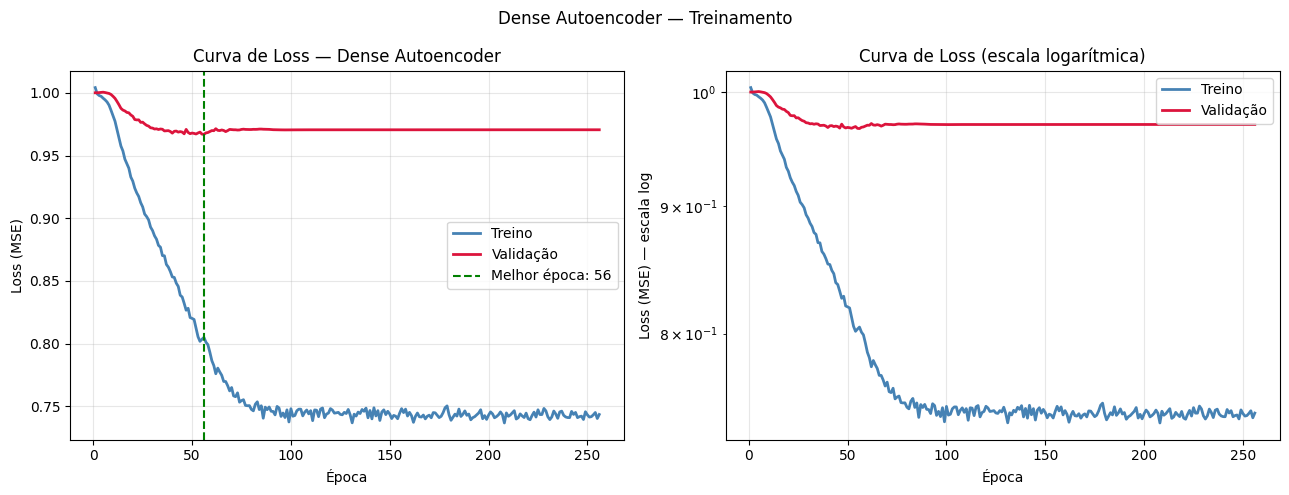

Diagnóstico:
  ⚠️  UNDERFITTING — loss ainda alta
     Sugestão: aumentar épocas ou aumentar capacidade da rede
  Train loss final : 0.743400
  Val   loss final : 0.970594
  Gap              : 0.227194


In [42]:
loss_treino = historico.history['loss']
loss_val    = historico.history['val_loss']
epocas      = range(1, len(loss_treino) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Loss completa ──────────────────────────────────────────────
ax = axes[0]
ax.plot(epocas, loss_treino, 'steelblue', lw=2, label='Treino')
ax.plot(epocas, loss_val,    'crimson',   lw=2, label='Validação')
ax.set_xlabel('Época')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Curva de Loss — Dense Autoencoder')
ax.legend()
ax.grid(True, alpha=0.3)

# Marcar melhor época
best_epoch = np.argmin(loss_val) + 1
ax.axvline(best_epoch, color='green', ls='--', lw=1.5,
           label=f'Melhor época: {best_epoch}')
ax.legend()

# ── Loss em escala log (facilita ver convergência) ─────────────
ax = axes[1]
ax.semilogy(epocas, loss_treino, 'steelblue', lw=2, label='Treino')
ax.semilogy(epocas, loss_val,    'crimson',   lw=2, label='Validação')
ax.set_xlabel('Época')
ax.set_ylabel('Loss (MSE) — escala log')
ax.set_title('Curva de Loss (escala logarítmica)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Dense Autoencoder — Treinamento', fontsize=12)
plt.tight_layout()
fig_path = os.path.join(PASTA_FIGS, "passo4_loss_curves.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Diagnóstico automático ────────────────────────────────────
gap = loss_val[-1] - loss_treino[-1]
print("Diagnóstico:")
if gap > 0.5 * loss_treino[-1]:
    print("  ⚠️  OVERFITTING detectado — val_loss muito maior que train_loss")
    print("     Sugestão: aumentar dropout ou reduzir épocas")
elif loss_treino[-1] > 0.5:
    print("  ⚠️  UNDERFITTING — loss ainda alta")
    print("     Sugestão: aumentar épocas ou aumentar capacidade da rede")
else:
    print("  ✅ Convergência adequada")
    
print(f"  Train loss final : {loss_treino[-1]:.6f}")
print(f"  Val   loss final : {loss_val[-1]:.6f}")
print(f"  Gap              : {gap:.6f}")


Erros de reconstrução (MSE):
  Ruído  treino  : média=0.7299  std=0.1223
  Ruído  val     : média=0.9669  std=0.0706
  Ruído  teste   : média=0.9607  std=0.0979
  Evento teste   : média=0.9722  std=0.0502
  Razão ev/ruído : 1.01x


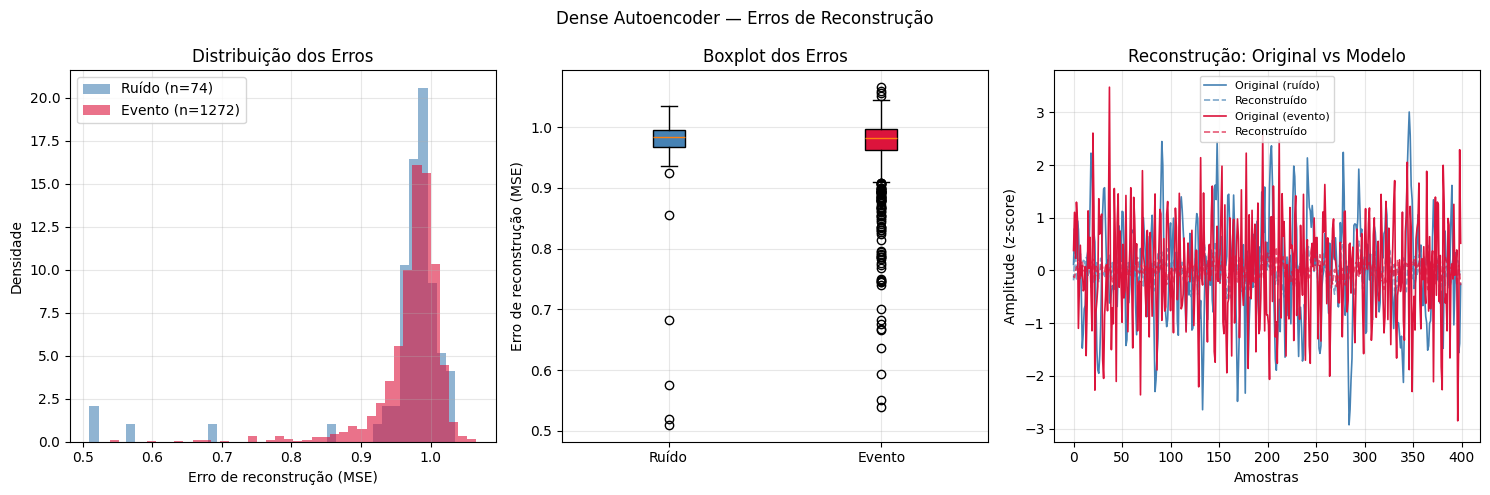


Interpretação:
  Histogramas separados → boa separabilidade → boa detecção
  Histogramas sobrepostos → modelo não distingue ruído de evento


In [43]:
# ── Carregar melhor modelo salvo ─────────────────────────────────
modelo_best = keras.models.load_model(model_path, compile=False)

def calcular_erros(modelo, X):
    """Calcula MSE de reconstrução para cada janela."""
    X_rec = modelo.predict(X, verbose=0)
    return np.mean((X - X_rec) ** 2, axis=1)

# Calcular erros
erros_treino = calcular_erros(modelo_best, X_train)
erros_val_n  = calcular_erros(modelo_best, X_val)
erros_test_n = calcular_erros(modelo_best, X_test_noise)
erros_val_e  = calcular_erros(modelo_best, X_val_events) if len(X_val_events) > 0 else np.array([])
erros_test_e = calcular_erros(modelo_best, X_test_events) if len(X_test_events) > 0 else np.array([])

print("Erros de reconstrução (MSE):")
print(f"  Ruído  treino  : média={erros_treino.mean():.4f}  std={erros_treino.std():.4f}")
print(f"  Ruído  val     : média={erros_val_n.mean():.4f}  std={erros_val_n.std():.4f}")
print(f"  Ruído  teste   : média={erros_test_n.mean():.4f}  std={erros_test_n.std():.4f}")
if len(erros_test_e) > 0:
    print(f"  Evento teste   : média={erros_test_e.mean():.4f}  std={erros_test_e.std():.4f}")
    razao = erros_test_e.mean() / max(erros_test_n.mean(), 1e-10)
    print(f"  Razão ev/ruído : {razao:.2f}x")

# ── Visualização ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histograma
ax = axes[0]
ax.hist(erros_test_n, bins=40, density=True, alpha=0.6,
        color='steelblue', label=f'Ruído (n={len(erros_test_n)})')
if len(erros_test_e) > 0:
    ax.hist(erros_test_e, bins=40, density=True, alpha=0.6,
            color='crimson', label=f'Evento (n={len(erros_test_e)})')
ax.set_xlabel('Erro de reconstrução (MSE)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição dos Erros')
ax.legend()
ax.grid(True, alpha=0.3)

# Boxplot
ax = axes[1]
data_box = [erros_test_n]
labels_box = ['Ruído']
if len(erros_test_e) > 0:
    data_box.append(erros_test_e)
    labels_box.append('Evento')
bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
if len(data_box) > 1:
    bp['boxes'][1].set_facecolor('crimson')
ax.set_ylabel('Erro de reconstrução (MSE)')
ax.set_title('Boxplot dos Erros')
ax.grid(True, alpha=0.3)

# Exemplos de reconstrução
ax = axes[2]
idx_ruido = np.random.randint(len(X_test_noise))
janela_r  = X_test_noise[idx_ruido]
recon_r   = modelo_best.predict(janela_r.reshape(1, -1), verbose=0).flatten()
ax.plot(janela_r, 'steelblue', lw=1.2, label='Original (ruído)')
ax.plot(recon_r,  'steelblue', lw=1.2, ls='--', alpha=0.7, label='Reconstruído')

if len(X_test_events) > 0:
    idx_ev   = np.random.randint(len(X_test_events))
    janela_e = X_test_events[idx_ev]
    recon_e  = modelo_best.predict(janela_e.reshape(1, -1), verbose=0).flatten()
    ax.plot(janela_e, 'crimson', lw=1.2, label='Original (evento)')
    ax.plot(recon_e,  'crimson', lw=1.2, ls='--', alpha=0.7, label='Reconstruído')

ax.set_xlabel('Amostras')
ax.set_ylabel('Amplitude (z-score)')
ax.set_title('Reconstrução: Original vs Modelo')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Dense Autoencoder — Erros de Reconstrução', fontsize=12)
plt.tight_layout()
fig_path = os.path.join(PASTA_FIGS, "passo4_erros_reconstrucao.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print()
print("Interpretação:")
print("  Histogramas separados → boa separabilidade → boa detecção")
print("  Histogramas sobrepostos → modelo não distingue ruído de evento")

## 8. Definindo o threshold e calculando métricas

Três estratégias de threshold:
1. **média + 3σ** do ruído de treino
2. **Percentil 95** do ruído de treino
3. **Ponto ótimo da curva ROC** (maximiza F1)


In [44]:
# Aquecer o modelo (descarta primeiras inferências — JIT warmup)
_ = modelo_best.predict(X_test_noise[:5], verbose=0)

# Medir 100 inferências de uma janela por vez (simula edge)
N_MEDICOES = 100
tempos = []
for _ in range(N_MEDICOES):
    janela = X_test_noise[np.random.randint(len(X_test_noise))].reshape(1,-1)
    t0 = time.perf_counter()
    _ = modelo_best.predict(janela, verbose=0)
    tempos.append((time.perf_counter() - t0) * 1000)  # ms

tempos = np.array(tempos)
print("Tempo de inferência (1 janela por vez):")
print(f"  Média  : {tempos.mean():.3f} ms")
print(f"  Std    : {tempos.std():.3f} ms")
print(f"  Min    : {tempos.min():.3f} ms")
print(f"  Max    : {tempos.max():.3f} ms")
print()

# Comparar com requisito de tempo real
JANELA_SEG   = 10.0
SOBREPOSICAO = 0.5
janelas_por_seg = 1 / (JANELA_SEG * (1 - SOBREPOSICAO))
print(f"Requisito tempo real: {1000/janelas_por_seg:.1f} ms por janela")
print(f"Tempo atual          : {tempos.mean():.1f} ms por janela")
if tempos.mean() < 1000/janelas_por_seg:
    print("✅ Modelo consegue rodar em tempo real")
else:
    print("⚠️  Modelo pode não rodar em tempo real — TFLite vai melhorar isso")

# Salvar tamanho do modelo
import os
tamanho_kb = os.path.getsize(model_path) / 1024
print(f"\nTamanho do modelo  : {tamanho_kb:.1f} KB")


Tempo de inferência (1 janela por vez):
  Média  : 48.199 ms
  Std    : 4.723 ms
  Min    : 41.745 ms
  Max    : 67.917 ms

Requisito tempo real: 5000.0 ms por janela
Tempo atual          : 48.2 ms por janela
✅ Modelo consegue rodar em tempo real

Tamanho do modelo  : 3491.7 KB


Thresholds calculados:
  média + 3σ  : 1.096895
  Percentil 95: 0.908048
  Ótimo ROC   : 0.539607

Threshold         Precisão     Recall         F1
------------------------------------------------
  média+3σ          0.0000     0.0000     0.0000
  p95               0.9452     0.9355     0.9403
  ótimo ROC         0.9464     1.0000     0.9725


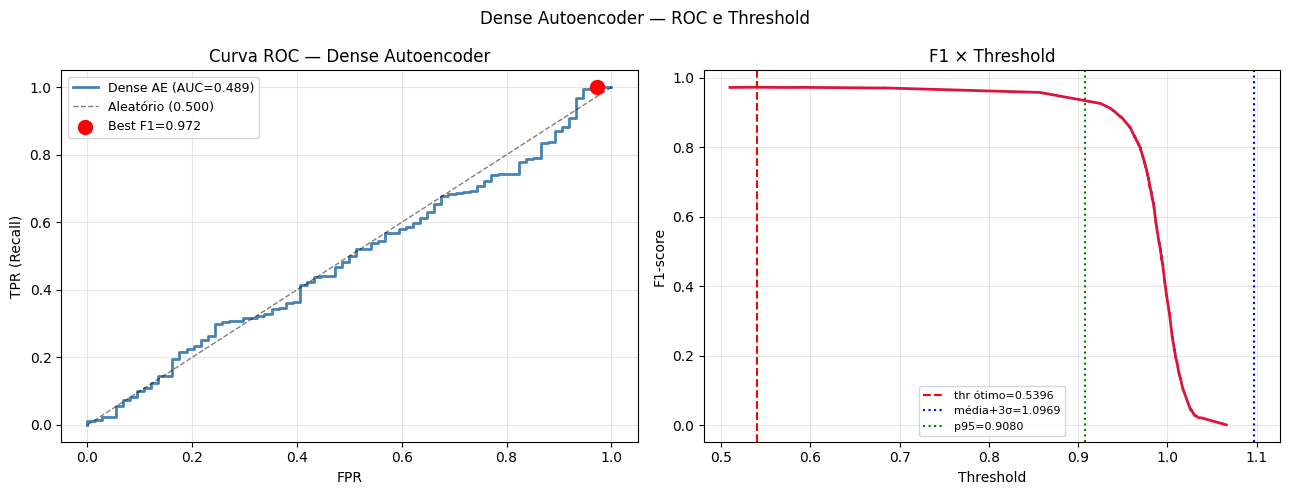

In [45]:
from sklearn.metrics import (roc_auc_score, roc_curve,
                             f1_score, precision_score, recall_score)

# ── Threshold 1: média + 3σ ───────────────────────────────────────
thr_3sigma = erros_treino.mean() + 3 * erros_treino.std()

# ── Threshold 2: percentil 95 ─────────────────────────────────────
thr_p95 = np.percentile(erros_treino, 95)

# ── Threshold 3: ponto ótimo da ROC ──────────────────────────────
if len(erros_test_e) > 0:
    y_scores = np.concatenate([erros_test_n, erros_test_e])
    y_true   = np.concatenate([np.zeros(len(erros_test_n)),
                               np.ones(len(erros_test_e))])
    
    fpr, tpr, thrs = roc_curve(y_true, y_scores)
    auc_score       = roc_auc_score(y_true, y_scores)
    
    f1_por_thr = [f1_score(y_true, (y_scores >= t).astype(int), zero_division=0)
                  for t in thrs]
    idx_best   = np.argmax(f1_por_thr)
    thr_roc    = thrs[idx_best]
    best_f1_roc= f1_por_thr[idx_best]
else:
    auc_score   = 0.0
    thr_roc     = thr_3sigma
    best_f1_roc = 0.0
    fpr = tpr = thrs = np.array([0,1])

print("Thresholds calculados:")
print(f"  média + 3σ  : {thr_3sigma:.6f}")
print(f"  Percentil 95: {thr_p95:.6f}")
print(f"  Ótimo ROC   : {thr_roc:.6f}")

# ── Métricas para cada threshold ─────────────────────────────────
print()
print(f"{'Threshold':15s} {'Precisão':>10s} {'Recall':>10s} {'F1':>10s}")
print("-" * 48)

for nome, thr in [("média+3σ", thr_3sigma),
                  ("p95",      thr_p95),
                  ("ótimo ROC",thr_roc)]:
    if len(erros_test_e) > 0:
        y_pred = (y_scores >= thr).astype(int)
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f = f1_score(y_true, y_pred, zero_division=0)
    else:
        p = r = f = 0.0
    print(f"  {nome:13s} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

# ── Curva ROC ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(fpr, tpr, 'steelblue', lw=2,
        label=f'Dense AE (AUC={auc_score:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Aleatório (0.500)')
ax.scatter(fpr[idx_best], tpr[idx_best], color='red', s=100, zorder=5,
           label=f'Best F1={best_f1_roc:.3f}')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR (Recall)')
ax.set_title('Curva ROC — Dense Autoencoder')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
if len(thrs) > 2:
    ax.plot(thrs, f1_por_thr, 'crimson', lw=2)
    ax.axvline(thr_roc, color='red', ls='--', lw=1.5,
               label=f'thr ótimo={thr_roc:.4f}')
    ax.axvline(thr_3sigma, color='blue', ls=':', lw=1.5,
               label=f'média+3σ={thr_3sigma:.4f}')
    ax.axvline(thr_p95, color='green', ls=':', lw=1.5,
               label=f'p95={thr_p95:.4f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1-score')
ax.set_title('F1 × Threshold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Dense Autoencoder — ROC e Threshold', fontsize=12)
plt.tight_layout()
fig_path = os.path.join(PASTA_FIGS, "passo4_roc.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()


In [46]:
# F1 final com threshold ótimo da ROC
if len(erros_test_e) > 0:
    f1_final = f1_score(y_true, (y_scores >= thr_roc).astype(int), zero_division=0)
    p_final  = precision_score(y_true, (y_scores >= thr_roc).astype(int), zero_division=0)
    r_final  = recall_score(y_true, (y_scores >= thr_roc).astype(int), zero_division=0)
else:
    f1_final = p_final = r_final = 0.0

print("=" * 65)
print("SEGUNDA LINHA DA TABELA COMPARATIVA — DENSE AUTOENCODER")
print("=" * 65)
print(f"  Épocas treinadas  : {len(historico.history['loss'])}")
print(f"  Latent dim        : {LATENT_DIM}")
print(f"  Threshold (ROC)   : {thr_roc:.6f}")
print(f"  Precisão          : {p_final:.4f}")
print(f"  Recall            : {r_final:.4f}")
print(f"  F1-score          : {f1_final:.4f}")
print(f"  AUC-ROC           : {auc_score:.4f}")
print(f"  Tamanho           : {tamanho_kb:.1f} KB")
print(f"  Inferência        : {tempos.mean():.3f} ms/janela")
print()

# Carregar resultado do STA/LTA para comparar
staltalvta_path = os.path.join(PASTA_RESULTS, "resultado_staltalvta_v2.json")
if os.path.exists(staltalvta_path):
    with open(staltalvta_path) as f:
        res_sta = json.load(f)
    
    print("Tabela parcial:")
    print(f"  {'Método':<15} {'F1':>8} {'AUC':>8} {'KB':>8} {'ms/jan':>10}")
    print(f"  {'-'*15} {'-'*8} {'-'*8} {'-'*8} {'-'*10}")
    print(f"  {'STA/LTA':<15} {res_sta['f1']:>8.4f} {res_sta['auc']:>8.4f} {'N/A':>8} {res_sta['inferencia_ms']:>10.4f}")
    print(f"  {'Dense AE':<15} {f1_final:>8.4f} {auc_score:>8.4f} {tamanho_kb:>8.1f} {tempos.mean():>10.3f}")
    print(f"  {'CNN 1D AE':<15} {'—':>8} {'—':>8} {'—':>8} {'—':>10}")
    print(f"  {'LSTM AE':<15} {'—':>8} {'—':>8} {'—':>8} {'—':>10}")

# Salvar resultado
resultado = {
    "metodo"        : "Dense Autoencoder",
    "versao"        : "1.0",
    "hiperparametros": {
        "latent_dim" : LATENT_DIM,
        "epochs"     : len(historico.history['loss']),
        "batch_size" : BATCH_SIZE,
        "lr"         : LR,
        "dropout"    : DROPOUT,
    },
    "threshold"     : float(thr_roc),
    "precisao"      : float(p_final),
    "recall"        : float(r_final),
    "f1"            : float(f1_final),
    "auc"           : float(auc_score),
    "tamanho_kb"    : float(tamanho_kb),
    "inferencia_ms" : float(tempos.mean()),
    "inferencia_std": float(tempos.std()),
    "tflite_kb"     : None,   # preenchido no Passo 8
    "tflite_quant_kb": None,
    "tflite_ms"     : None,
    "tflite_quant_ms": None,
}

result_path = os.path.join(PASTA_RESULTS, "resultado_dense_ae.json")
with open(result_path, 'w') as f:
    json.dump(resultado, f, indent=2)

print(f"\n💾 Resultado salvo: {result_path}")
print("\n🚀 Passo 4 concluído → Próximo: Passo 5 — CNN 1D Autoencoder")


SEGUNDA LINHA DA TABELA COMPARATIVA — DENSE AUTOENCODER
  Épocas treinadas  : 256
  Latent dim        : 32
  Threshold (ROC)   : 0.539607
  Precisão          : 0.9464
  Recall            : 1.0000
  F1-score          : 0.9725
  AUC-ROC           : 0.4895
  Tamanho           : 3491.7 KB
  Inferência        : 48.199 ms/janela


💾 Resultado salvo: C:\Users\vish8\OneDrive\Documentos\GitHub\TCC\Trabalho\artefacts\results\results\resultado_dense_ae.json

🚀 Passo 4 concluído → Próximo: Passo 5 — CNN 1D Autoencoder
